## Imports



In [1]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import time
import numpy as np
import random

from dataset import RobotControlDataset
from performance_boosting import PBClosedLoop, PBLoss, PinballLossWrapper, CVaRLossWrapper
from ren import ContractiveREN
from robot import RobotPlant, ProportionalController, StabilizedRobot
from plot_functions import plot_pb_trajectories, plot_trajectories

## Simulation parameters

In [2]:
#setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#TODO: to device

#seed
seed = 1

#dataset parameters
x0_std = 0.2
noise_std = 0.

#controller parameters
x_target = torch.zeros(4)
kp = 1.

#physics parameters
n_agents = 1
state_dim = 4
input_dim = 2
dt = 0.05

#nominal model parameters
b_nom = 1
m_nom = 1
b2_nom = 0.2

#simulator parameters
b_sim = 1
m_sim = 1
b2_sim = 0.2

#ren parameters
initialization_std = 0.1
dim_internal = 4
dim_nl = 4

# --- 2. Loss Parameters (Q and R) ---
# Base Q for 1 agent: Penalize pos_x, pos_y, vel_x, vel_y shape (4, 4)
alpha_x = 1
Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * alpha_x
# Expand Q for N agents (Block Diagonal): (4 * n_agents, 4 * n_agents)
Q = torch.kron(torch.eye(n_agents), Q_agent)

# Base R for 1 agent: Penalize force_x, force_y shape (2, 2)
alpha_u = 0.0002
R_agent = torch.eye(2) * alpha_u
# Expand R for N agents: (2 * n_agents, 2 * n_agents)
R = torch.kron(torch.eye(n_agents), R_agent)

# Weight for obstacle avoidance
alpha_obs = 100.0

# --- 3. Obstacles Parameters ---
obs_centers = [torch.tensor([-0.5, -0.5])]
obs_sigmas  = [torch.tensor([0.2, 0.2])]

# --- 4. Target State: All agents to go to origin (0,0) with 0 velocity.
x_target = torch.zeros(4 * n_agents)

#------ 5. Wrapper_parameters----------
cvar_wrapper = True
pinball_wrapper = not cvar_wrapper
conditional_training = False
#true certification goals
alpha_true = 0.05       # You want the real-world worst 5% targets 95% confidence
delta = 0.01            # With 99% confidence
m_cert = 2000           # Size of your final certification batch
#Calculate the penalty term (epsilon)
if conditional_training:
    epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert))
else:
    epsilon_cert = 0
# Shift training alpha!
alpha_train = alpha_true - epsilon_cert

#--------6. training parameters------------
num_trajectories = 3000
train_size =  int(num_trajectories/3)
val_size = int(num_trajectories/3)
test_size = int(num_trajectories/3)
batch_size = 500
horizon = 500
num_epochs = 200
lr = 0.001

#validation
N = 10 #number of validation scenarios

## Set seed

In [3]:
seed = seed  # Choose any fixed number
torch.manual_seed(seed)
np.random.seed(seed)

## Dataset and Dataloader

In [4]:
# Initialize Dataset and Loader
dataset = RobotControlDataset(num_trajectories, horizon, n_agents, x0_std, noise_std)

# Split dataset
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Simulator, nominal model and stabilizing controller

In [5]:
#Open loop real plant (unknown)
sim_OL_plant = RobotPlant(b = b_sim, b2 = b2_sim, m = m_sim, n_agents = n_agents).to(device)
#Open loop nominal model
nominal_OL_plant = RobotPlant(b = b_nom, b2 = b2_nom, m = m_nom, n_agents = n_agents).to(device)
#Proportional controller
base_controller = ProportionalController(kp = kp, n_agents = n_agents).to(device)
#Stabilized real plant (closed loop of real plant and base controller) (unknown)
f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(device)
#Stabilized nominal model (closed loop of nominal model and base controller) (I could use a different controller as long as this is a stable closed loop or if I use the base controller of the real plant I have to make sure it stabilizes my model as well)
f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(device)

#Freeze the physics/nominal models
for param in f_sim.parameters():
    param.requires_grad = False
for param in f_nom.parameters():
    param.requires_grad = False

## Plot closed loop trajectories with base controller

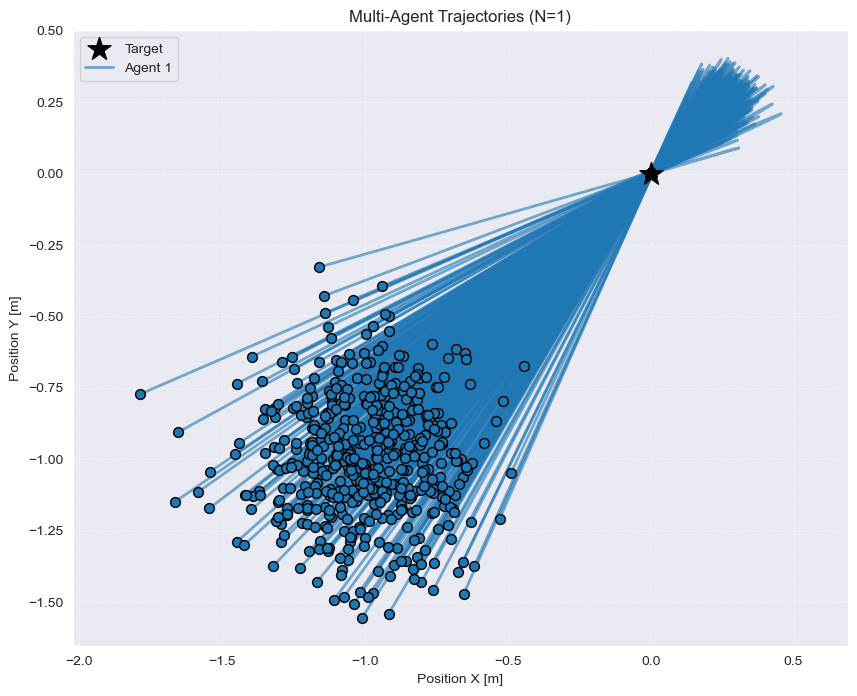

In [6]:
# #sample 10 initial conditions
x0 = dataset.x0_data[:batch_size, :1, :]
u_ext = torch.zeros(batch_size, horizon, input_dim *  n_agents)
traj_y_real = f_sim(x0, horizon, batch_size, u_ext=u_ext, output_noise=None)
# # Run the plotter
plot_trajectories(traj_y_real)

## Empirical Risk Minimization training (no model mismatch)


### Define simulated model

In [7]:
#Ren
ren = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim = PBClosedLoop(ren, f_sim, f_nom).to(device)

### Training loop


Starting training on cpu...
Epoch 1/200 | Train Loss: 2.5521 | Val Loss: 2.5121 | Time: 1.70s (Total: 1.70 sec)
Epoch 2/200 | Train Loss: 2.5464 | Val Loss: 2.5078 | Time: 1.47s (Total: 3.16 sec)
Epoch 3/200 | Train Loss: 2.5424 | Val Loss: 2.5044 | Time: 1.44s (Total: 4.61 sec)
Epoch 4/200 | Train Loss: 2.5393 | Val Loss: 2.5012 | Time: 1.36s (Total: 5.97 sec)
Epoch 5/200 | Train Loss: 2.5360 | Val Loss: 2.4976 | Time: 1.54s (Total: 7.51 sec)
Epoch 6/200 | Train Loss: 2.5323 | Val Loss: 2.4935 | Time: 2.05s (Total: 9.56 sec)
Epoch 7/200 | Train Loss: 2.5282 | Val Loss: 2.4885 | Time: 2.27s (Total: 11.83 sec)
Epoch 8/200 | Train Loss: 2.5230 | Val Loss: 2.4821 | Time: 1.69s (Total: 13.51 sec)
Epoch 9/200 | Train Loss: 2.5164 | Val Loss: 2.4732 | Time: 1.41s (Total: 14.93 sec)
Epoch 10/200 | Train Loss: 2.5070 | Val Loss: 2.4605 | Time: 1.49s (Total: 16.42 sec)
Epoch 11/200 | Train Loss: 2.4928 | Val Loss: 2.4417 | Time: 1.38s (Total: 17.80 sec)
Epoch 12/200 | Train Loss: 2.4726 | Val L

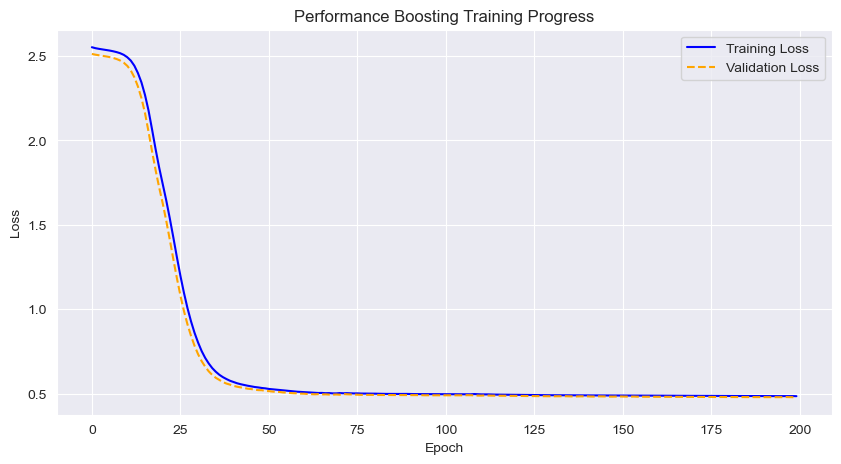

In [8]:
#Instantiate loss and Move to Device
loss_fn = PBLoss(x_target, Q, R, alpha_obs=alpha_obs,
                 obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents)

loss_fn.to(device) #Moves Q, R, target, and obstacles to GPU

optimizer = torch.optim.Adam(PB_closed_loop_sim.parameters(), lr=lr)

# Lists to store history for plotting
train_losses = []
all_traj_x_val= []
all_traj_u_val = []
all_traj_w_hat_val = []
val_losses = []

# Track total training time
start_time = time.time()

print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    # --- TRAINING PHASE ---
    PB_closed_loop_sim.train()  # Set model to training mode
    total_train_loss = 0

    for batch_w in train_loader:
        # Move the entire batch to device
        batch_w = batch_w.to(device)

        optimizer.zero_grad()

        # 1. Run Simulation
        # The controller generates the full trajectory based on input w
        traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim.run(batch_w)

        # 2. Compute Loss
        # Note: Your loss_fn returns (total_loss, breakdown_dict_or_values)
        loss, _, _, _ = loss_fn(traj_x_train, traj_u_train)

        # 3. Backprop
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # Compute average training loss for this epoch
    avg_train_loss = total_train_loss / len(train_loader) if len(train_loader) > 0 else 0
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    PB_closed_loop_sim.eval()  # Set model to evaluation mode (disable dropout, etc.)
    total_val_loss = 0

    with torch.no_grad():  # Disable gradient calculation for efficiency
        for batch_w_val in val_loader:
            batch_w_val = batch_w_val.to(device)

            # Run simulation without storing gradients
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim.run(batch_w_val)

            # Compute validation loss
            val_loss, _, _, _ = loss_fn(traj_x_val, traj_u_val)
            total_val_loss += val_loss.item()

    # Compute average validation loss
    avg_val_loss = total_val_loss / len(val_loader) if len(val_loader) > 0 else 0
    val_losses.append(avg_val_loss)

    # --- LOGGING ---
    epoch_duration = time.time() - epoch_start_time
    elapsed_time = time.time() - start_time

    # Print progress every epoch (or every N epochs to reduce clutter)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Time: {epoch_duration:.2f}s (Total: {elapsed_time:.2f} sec)")

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Performance Boosting Training Progress')
plt.legend()
plt.grid(True)
plt.show()

### Plots


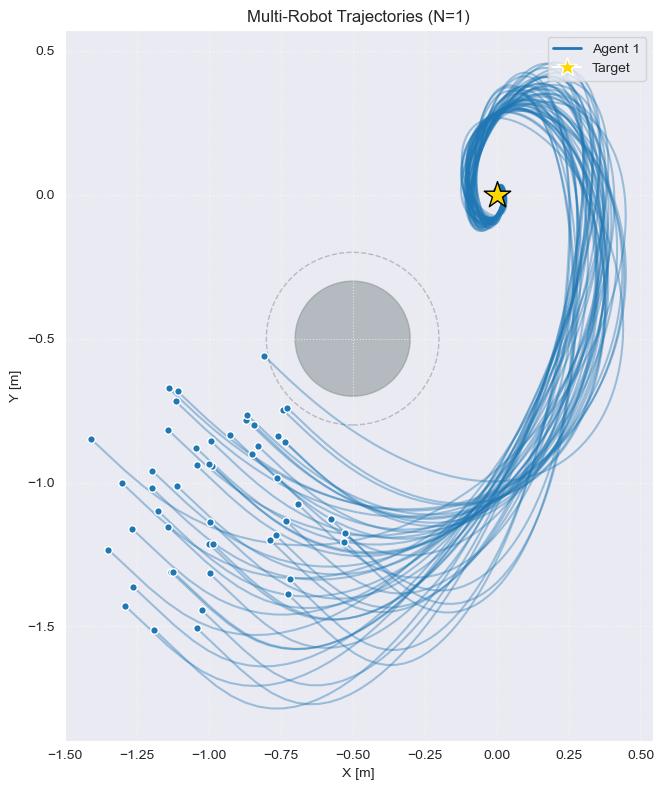

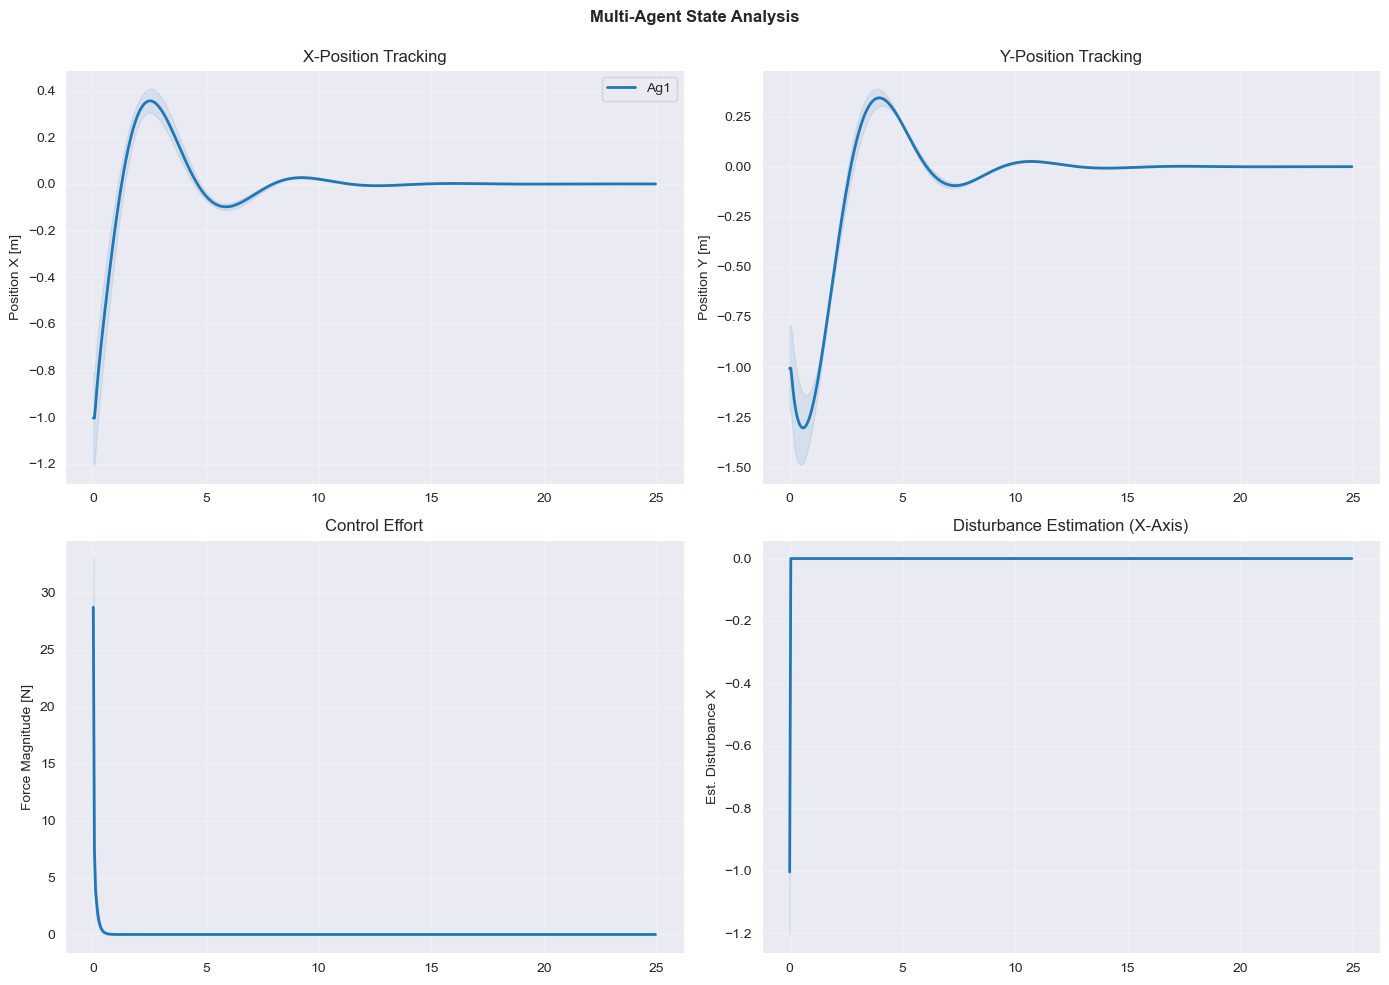

In [9]:
plot_pb_trajectories(
    traj_x=traj_x_val,
    traj_u=traj_u_val,
    traj_w_hat=traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

### Testing

Starting testing on cpu...
Testing Complete. Average Test Loss: 0.4781


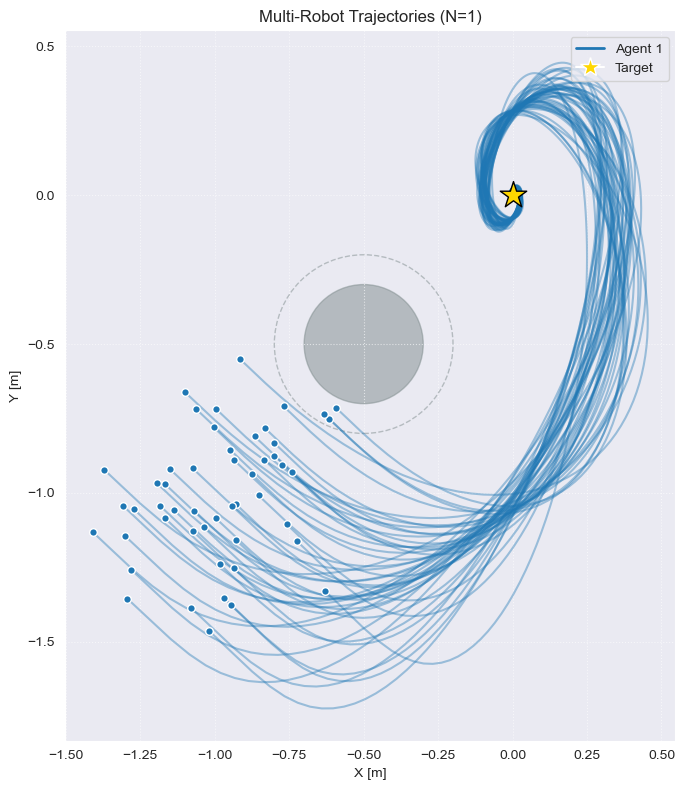

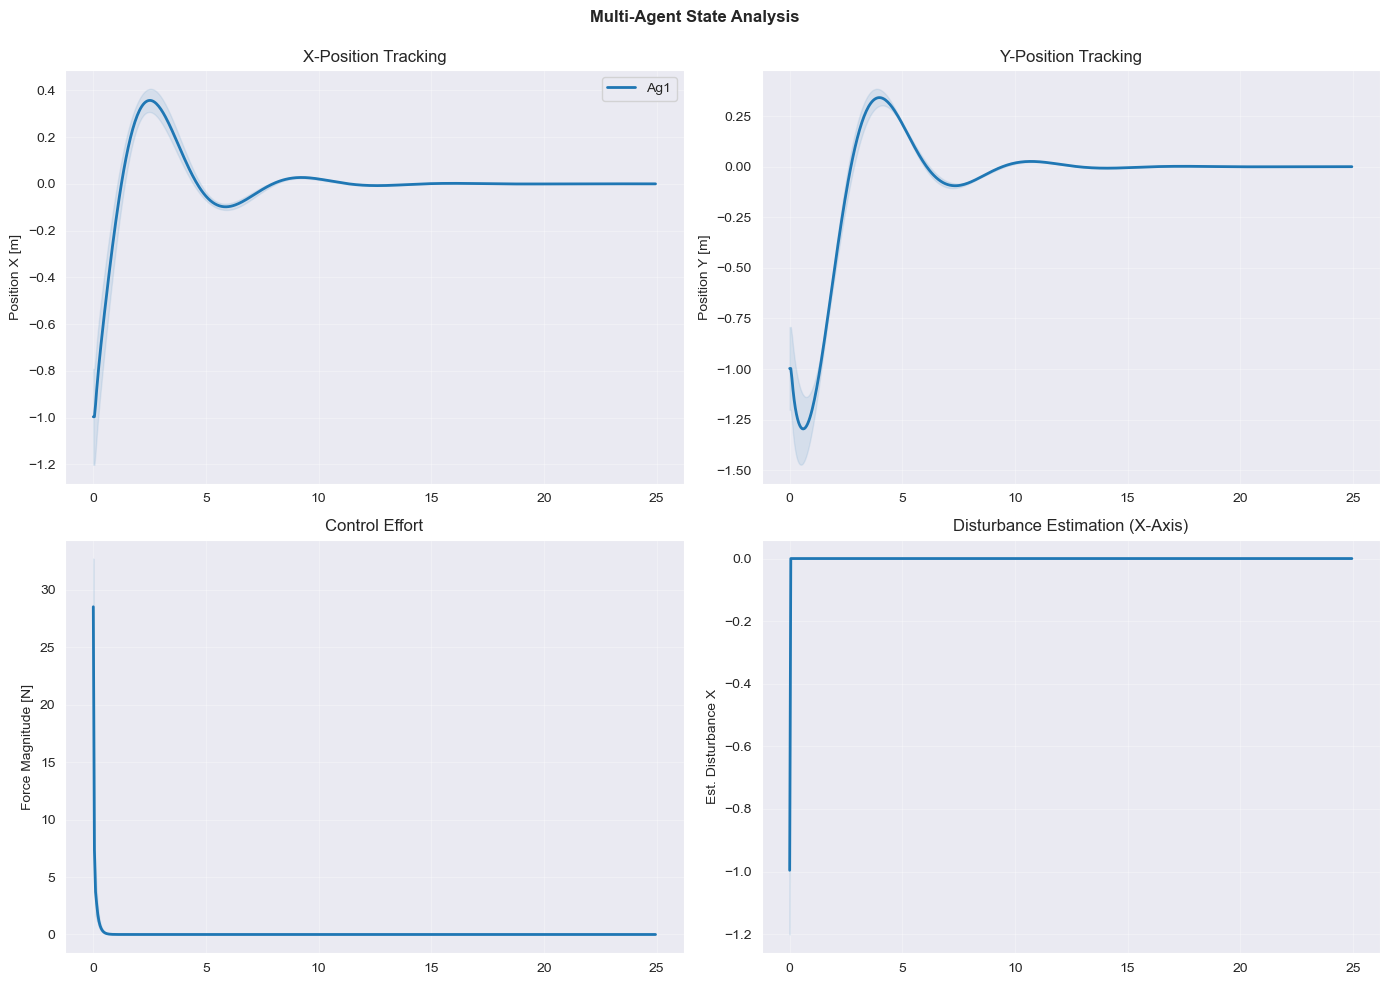

In [10]:
# --- PREPARATION ---
PB_closed_loop_sim.eval()  # Set model to evaluation mode
test_losses = []


print(f"Starting testing on {device}...")

# --- TESTING LOOP ---
with torch.no_grad():
    for i, batch_w_test in enumerate(test_loader):
        batch_w_test = batch_w_test.to(device)

        # 1. Run Simulation
        # The controller generates the trajectories for the test batch
        traj_x_test, traj_u_test, traj_w_hat_test = PB_closed_loop_sim.run(batch_w_test)

        # 2. Compute Test Loss (Optional, for metric tracking)
        loss, _, _, _ = loss_fn(traj_x_test, traj_u_test)
        test_losses.append(loss.item())


# Calculate average loss
avg_test_loss = sum(test_losses) / len(test_loader)
print(f"Testing Complete. Average Test Loss: {avg_test_loss:.4f}")

plot_pb_trajectories(
    traj_x=traj_x_test,
    traj_u=traj_u_test,
    traj_w_hat=traj_w_hat_test,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt)

## Quantile-oriented training

### Define simulated model

In [11]:
#Ren
ren_quantile = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_quantile = PBClosedLoop(ren_quantile, f_sim, f_nom).to(device)

### Training loop

In [ ]:
#Instantiate metric and Move to Device
metric = PBLoss(x_target, Q, R, alpha_obs=alpha_obs,
                 obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents)

metric.to(device)  #Moves Q, R, target, and obstacles to GPU

# 1. Setup Loss Wrapper
if cvar_wrapper:
    loss_wrapper = CVaRLossWrapper(alpha=alpha_train, metric=metric)
elif pinball_wrapper:
    loss_wrapper = PinballLossWrapper(alpha=alpha_train, metric=metric)
loss_wrapper.to(device) # Moves tau to GPU

# We must optimize controller and tau (threshold) simultaneously
optimizer = torch.optim.Adam(
    list(PB_closed_loop_sim_quantile.parameters()) + [loss_wrapper.tau],
    lr=lr
)

# Lists to store history for plotting
train_losses = []
val_losses = []

# Track total training time
start_time = time.time()

print(f"Starting training on {device}...")

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    # --- TRAINING PHASE ---
    PB_closed_loop_sim_quantile.train()  # Set model to training mode
    total_train_loss = 0

    for batch_w in train_loader:
        # Move the entire batch to device
        batch_w = batch_w.to(device)

        optimizer.zero_grad()

        # 1. Run Simulation
        # The controller generates the full trajectory based on input w
        traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_quantile.run(batch_w)

        # 2. Compute Loss (Using Wrapper)
        # We ignore the extra returns for the backward pass
        loss, performance_scores = loss_wrapper(traj_x_train, traj_u_train)

        # 3. Backprop
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # Compute average training loss for this epoch
    avg_train_loss = total_train_loss / len(train_loader) if len(train_loader) > 0 else 0
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    PB_closed_loop_sim_quantile.eval()  # Set model to evaluation mode (disable dropout, etc.)
    total_val_loss = 0

    with torch.no_grad():  # Disable gradient calculation for efficiency
        for batch_w_val in val_loader:
            batch_w_val = batch_w_val.to(device)

            # Run simulation without storing gradients
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_quantile.run(batch_w_val)

            # Compute validation loss
            val_loss, _ = loss_wrapper(traj_x_val, traj_u_val)
            total_val_loss += val_loss.item()

    # Compute average validation loss
    avg_val_loss = total_val_loss / len(val_loader) if len(val_loader) > 0 else 0
    val_losses.append(avg_val_loss)

    # --- LOGGING ---
    epoch_duration = time.time() - epoch_start_time
    elapsed_time = time.time() - start_time

    # tau
    current_tau = loss_wrapper.tau.item()

    print(f"Epoch {epoch + 1}/{num_epochs} | "
          f"CVaR Train Loss: {avg_train_loss:.4f} | "
          f"CVaR Val Loss: {avg_val_loss:.4f} | "
          f"Tau (95% Quantile): {current_tau:.4f} | "
          f"Time: {epoch_duration:.2f}s")

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Performance Boosting Training Progress')
plt.legend()
plt.grid(True)
plt.show()

Starting training on cpu...
Epoch 1/200 | CVaR Train Loss: 188.7139 | CVaR Val Loss: 185.7330 | Tau (95% Quantile): 0.0020 | Time: 1.73s
Epoch 2/200 | CVaR Train Loss: 188.1127 | CVaR Val Loss: 185.1731 | Tau (95% Quantile): 0.0040 | Time: 1.78s
Epoch 3/200 | CVaR Train Loss: 187.5435 | CVaR Val Loss: 184.6011 | Tau (95% Quantile): 0.0060 | Time: 1.88s
Epoch 4/200 | CVaR Train Loss: 186.9480 | CVaR Val Loss: 183.9641 | Tau (95% Quantile): 0.0080 | Time: 1.91s
Epoch 5/200 | CVaR Train Loss: 186.2425 | CVaR Val Loss: 183.2019 | Tau (95% Quantile): 0.0100 | Time: 1.45s
Epoch 6/200 | CVaR Train Loss: 185.4082 | CVaR Val Loss: 182.2777 | Tau (95% Quantile): 0.0120 | Time: 1.47s
Epoch 7/200 | CVaR Train Loss: 184.4343 | CVaR Val Loss: 181.2065 | Tau (95% Quantile): 0.0140 | Time: 1.53s
Epoch 8/200 | CVaR Train Loss: 183.2949 | CVaR Val Loss: 180.0311 | Tau (95% Quantile): 0.0160 | Time: 1.39s
Epoch 9/200 | CVaR Train Loss: 182.0844 | CVaR Val Loss: 178.7427 | Tau (95% Quantile): 0.0180 | Tim

### Plots


In [ ]:
plot_pb_trajectories(
    traj_x=traj_x_val,
    traj_u=traj_u_val,
    traj_w_hat=traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

### Testing

In [ ]:
# --- PREPARATION ---
PB_closed_loop_sim_quantile.eval()  # Set model to evaluation mode
test_losses = []

print(f"Starting testing on {device}...")

# --- TESTING LOOP ---
with torch.no_grad():
    for i, batch_w_test in enumerate(test_loader):
        batch_w_test = batch_w_test.to(device)

        # 1. Run Simulation
        # The controller generates the trajectories for the test batch
        traj_x_test, traj_u_test, traj_w_hat_test = PB_closed_loop_sim_quantile.run(batch_w_test)

        # 2. Compute Test Loss (Optional, for metric tracking)
        loss, _ = loss_wrapper(traj_x_test, traj_u_test)
        test_losses.append(loss.item())

# Calculate average loss
avg_test_loss = sum(test_losses) / len(test_loader)
print(f"Testing Complete. Average Test Loss: {avg_test_loss:.4f}")

plot_pb_trajectories(
    traj_x=traj_x_test,
    traj_u=traj_u_test,
    traj_w_hat=traj_w_hat_test,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt)